# Wind Power Forecast Error Analysis
## UK National Wind Generation - January 2024

This notebook analyzes the accuracy of wind power generation forecasts from the BMRS (Balancing Mechanism Reporting Service) WINDFOR dataset, compared against actual generation data from the FUELHH dataset.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.15

## 1. Load Data

In [2]:
# Load pre-fetched data
with open('../public/data/actuals.json') as f:
    actuals_raw = json.load(f)
with open('../public/data/forecasts.json') as f:
    forecasts_raw = json.load(f)

# Convert to DataFrames
df_actual = pd.DataFrame(actuals_raw)
df_actual['startTime'] = pd.to_datetime(df_actual['startTime'])
df_actual = df_actual.sort_values('startTime').drop_duplicates('startTime').reset_index(drop=True)

df_forecast = pd.DataFrame(forecasts_raw)
df_forecast['startTime'] = pd.to_datetime(df_forecast['startTime'])
df_forecast['publishTime'] = pd.to_datetime(df_forecast['publishTime'])

# Compute forecast horizon in hours
df_forecast['horizon_hours'] = (df_forecast['startTime'] - df_forecast['publishTime']).dt.total_seconds() / 3600

print(f"Actual data points: {len(df_actual)}")
print(f"Forecast data points: {len(df_forecast)}")
print(f"\nActual date range: {df_actual['startTime'].min()} to {df_actual['startTime'].max()}")
print(f"Forecast horizon range: {df_forecast['horizon_hours'].min():.1f}h to {df_forecast['horizon_hours'].max():.1f}h")

Actual data points: 1489
Forecast data points: 9582

Actual date range: 2023-12-31 23:30:00+00:00 to 2024-01-31 23:30:00+00:00
Forecast horizon range: 0.5h to 48.0h


## 2. Match Forecasts to Actuals

For each target time, we find the latest forecast that was published at least 4 hours before. We also compute errors across all forecast horizons.

In [3]:
# Merge forecasts with actuals on startTime
df_merged = df_forecast.merge(df_actual[['startTime', 'generation']], on='startTime', suffixes=('_forecast', '_actual'))

# Compute errors
df_merged['error'] = df_merged['generation_forecast'] - df_merged['generation_actual']
df_merged['abs_error'] = df_merged['error'].abs()
df_merged['pct_error'] = (df_merged['abs_error'] / df_merged['generation_actual'].abs().clip(lower=1)) * 100

# Add time-of-day features
df_merged['hour'] = df_merged['startTime'].dt.hour
df_merged['day'] = df_merged['startTime'].dt.date

print(f"Matched forecast-actual pairs: {len(df_merged)}")
df_merged.head()

Matched forecast-actual pairs: 9200


,startTime,publishTime,generation_forecast,horizon_hours,generation_actual,error,abs_error,pct_error,hour,day
0,2024-01-01 21:00:00+00:00,2024-01-01 02:30:00+00:00,9426,18.5,13953,-4527,4527,32.444636,21,2024-01-01
1,2024-01-01 21:00:00+00:00,2024-01-01 04:30:00+00:00,9432,16.5,13953,-4521,4521,32.401634,21,2024-01-01
2,2024-01-01 21:00:00+00:00,2024-01-01 07:30:00+00:00,10065,13.5,13953,-3888,3888,27.864975,21,2024-01-01
3,2024-01-01 21:00:00+00:00,2024-01-01 09:30:00+00:00,10065,11.5,13953,-3888,3888,27.864975,21,2024-01-01
4,2024-01-01 21:00:00+00:00,2024-01-01 11:30:00+00:00,10072,9.5,13953,-3881,3881,27.814807,21,2024-01-01


## 3. Overall Error Statistics

In [4]:
# Compute aggregate error metrics
errors = df_merged['abs_error']
signed_errors = df_merged['error']

stats = {
    'Mean Absolute Error (MAE)': errors.mean(),
    'Median Absolute Error': errors.median(),
    'P90 Absolute Error': errors.quantile(0.90),
    'P95 Absolute Error': errors.quantile(0.95),
    'P99 Absolute Error': errors.quantile(0.99),
    'Root Mean Square Error (RMSE)': np.sqrt((signed_errors**2).mean()),
    'Mean Absolute % Error (MAPE)': df_merged['pct_error'].mean(),
    'Mean Bias Error': signed_errors.mean(),
    'Std Dev of Error': signed_errors.std(),
}

stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])
stats_df['Value'] = stats_df['Value'].round(1)
print("=" * 50)
print("OVERALL ERROR STATISTICS (All forecasts)")
print("=" * 50)
for name, val in stats.items():
    unit = '%' if 'MAPE' in name else 'MW'
    print(f"  {name:35s}: {val:>8.1f} {unit}")

OVERALL ERROR STATISTICS (All forecasts)
  Mean Absolute Error (MAE)          :   2071.5 MW
  Median Absolute Error              :   1806.5 MW
  P90 Absolute Error                 :   4218.0 MW
  P95 Absolute Error                 :   4784.2 MW
  P99 Absolute Error                 :   7189.4 MW
  Root Mean Square Error (RMSE)      :   2654.6 MW
  Mean Absolute % Error (MAPE)       :   2359.2 %
  Mean Bias Error                    :   1406.9 MW
  Std Dev of Error                   :   2251.2 MW


## 4. Error Distribution

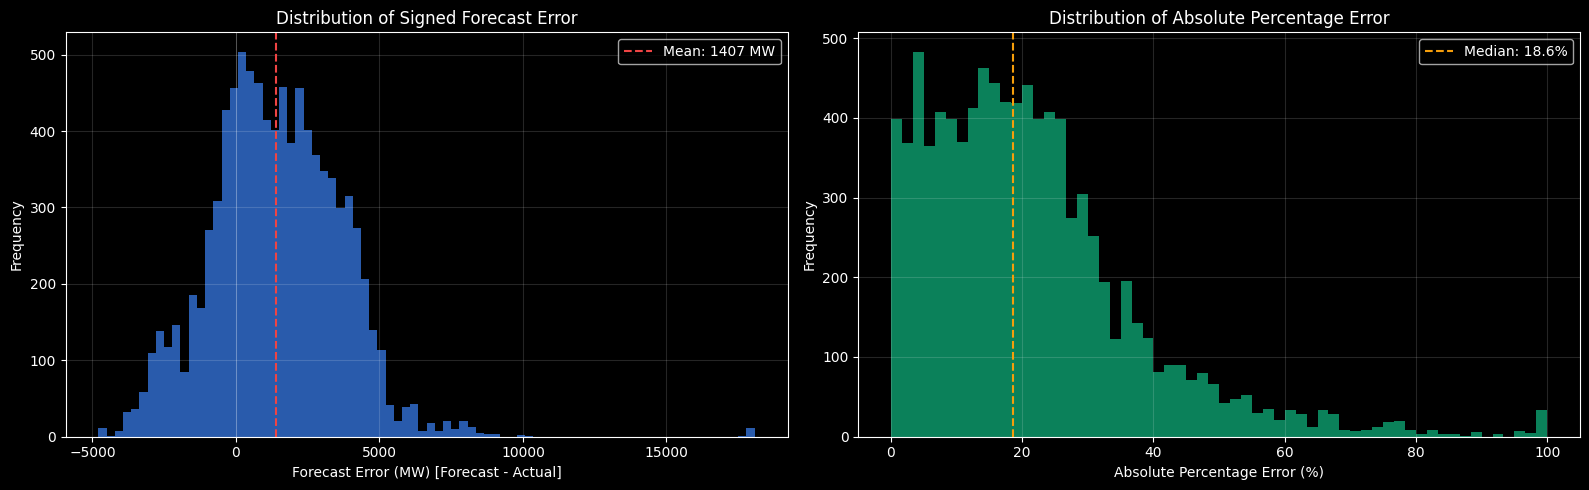

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Signed error distribution
axes[0].hist(signed_errors, bins=80, color='#3b82f6', alpha=0.7, edgecolor='none')
axes[0].axvline(signed_errors.mean(), color='#ef4444', linestyle='--', linewidth=1.5, label=f'Mean: {signed_errors.mean():.0f} MW')
axes[0].axvline(0, color='#ffffff', linestyle='-', linewidth=0.5, alpha=0.3)
axes[0].set_xlabel('Forecast Error (MW) [Forecast - Actual]')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Signed Forecast Error')
axes[0].legend()

# Absolute percentage error distribution
pct_clipped = df_merged['pct_error'].clip(upper=100)
axes[1].hist(pct_clipped, bins=60, color='#10b981', alpha=0.7, edgecolor='none')
axes[1].axvline(df_merged['pct_error'].median(), color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Median: {df_merged["pct_error"].median():.1f}%')
axes[1].set_xlabel('Absolute Percentage Error (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Absolute Percentage Error')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Error vs Forecast Horizon

How does forecast accuracy degrade as the forecast horizon increases?

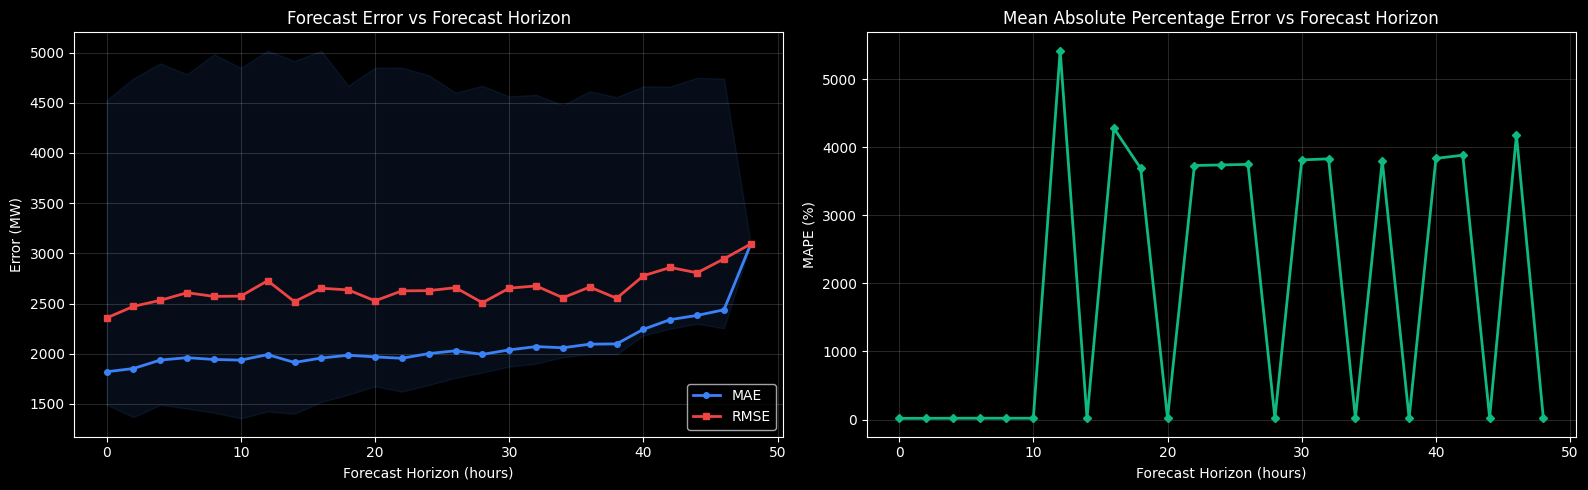


Error by Forecast Horizon (summary):
 horizon_bin    MAE   RMSE   MAPE  count
         0.0 1821.0 2357.0   17.6     61
         2.0 1853.3 2472.3   17.9    122
         4.0 1937.6 2532.6   19.0    152
         6.0 1961.4 2608.4   19.5    183
         8.0 1943.4 2571.6   19.1    212
        10.0 1936.9 2574.4   19.3    273
        12.0 1991.8 2728.0 5419.8    333
        14.0 1913.6 2519.1   19.1    362
        16.0 1957.8 2652.7 4280.8    422
        18.0 1985.6 2636.5 3691.7    483
        20.0 1969.3 2527.1   19.9    481
        22.0 1955.2 2627.0 3733.0    480
        24.0 2002.2 2628.8 3741.4    479
        26.0 2029.8 2658.8 3749.4    478
        28.0 1994.1 2508.3   20.2    477
        30.0 2038.7 2653.7 3814.8    476
        32.0 2071.7 2675.9 3831.1    474
        34.0 2060.0 2558.4   21.3    474
        36.0 2095.7 2664.9 3803.1    472
        38.0 2098.6 2552.7   22.3    470
        40.0 2244.2 2777.5 3837.7    468
        42.0 2340.5 2859.9 3884.4    467
        44.0 2382.4

In [6]:
# Bin forecasts by horizon in 2-hour buckets
df_merged['horizon_bin'] = (df_merged['horizon_hours'] // 2) * 2

horizon_stats = df_merged.groupby('horizon_bin').agg(
    MAE=('abs_error', 'mean'),
    RMSE=('error', lambda x: np.sqrt((x**2).mean())),
    MAPE=('pct_error', 'mean'),
    median_error=('abs_error', 'median'),
    p95_error=('abs_error', lambda x: x.quantile(0.95)),
    count=('abs_error', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MAE & RMSE vs Horizon
axes[0].plot(horizon_stats['horizon_bin'], horizon_stats['MAE'], 'o-', color='#3b82f6', linewidth=2, markersize=4, label='MAE')
axes[0].plot(horizon_stats['horizon_bin'], horizon_stats['RMSE'], 's-', color='#ef4444', linewidth=2, markersize=4, label='RMSE')
axes[0].fill_between(horizon_stats['horizon_bin'], horizon_stats['median_error'], horizon_stats['p95_error'], alpha=0.1, color='#3b82f6')
axes[0].set_xlabel('Forecast Horizon (hours)')
axes[0].set_ylabel('Error (MW)')
axes[0].set_title('Forecast Error vs Forecast Horizon')
axes[0].legend()

# MAPE vs Horizon
axes[1].plot(horizon_stats['horizon_bin'], horizon_stats['MAPE'], 'D-', color='#10b981', linewidth=2, markersize=4)
axes[1].set_xlabel('Forecast Horizon (hours)')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Mean Absolute Percentage Error vs Forecast Horizon')

plt.tight_layout()
plt.show()

print("\nError by Forecast Horizon (summary):")
print(horizon_stats[['horizon_bin', 'MAE', 'RMSE', 'MAPE', 'count']].to_string(index=False, float_format='%.1f'))

## 6. Error by Time of Day

Does forecast accuracy vary depending on the time of day (e.g., peak vs off-peak)?

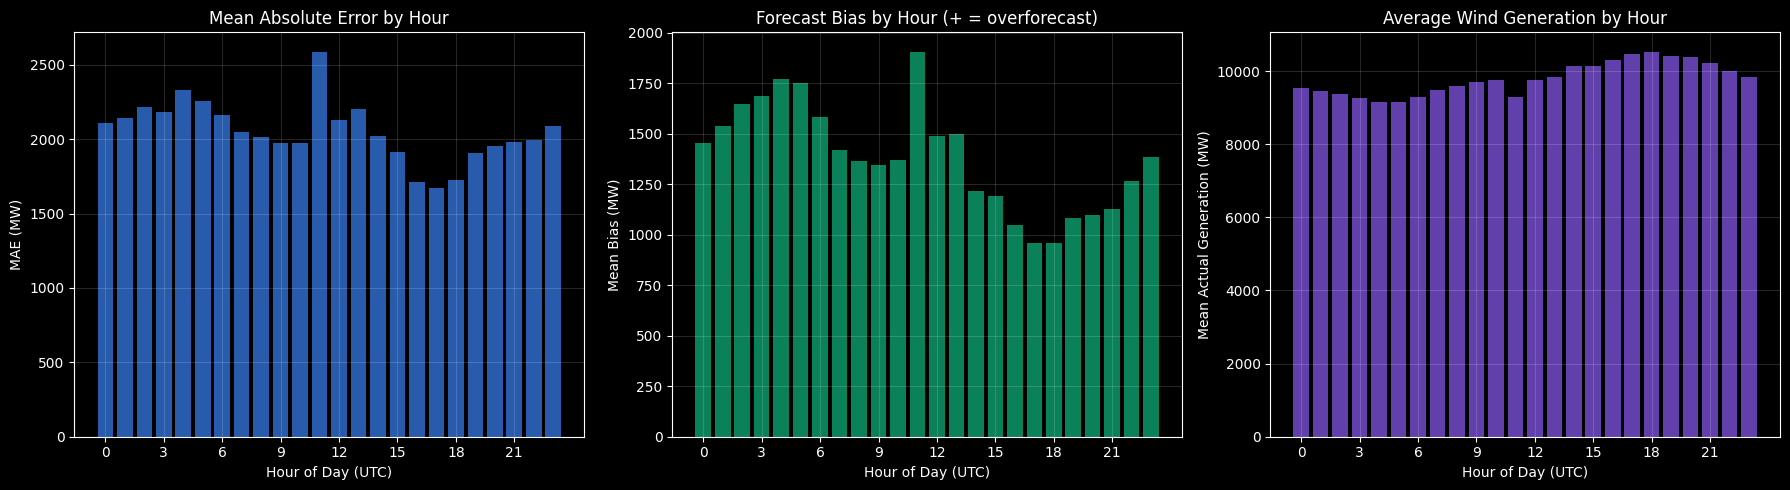

In [7]:
# Group by hour-of-day
hourly_stats = df_merged.groupby('hour').agg(
    MAE=('abs_error', 'mean'),
    MAPE=('pct_error', 'mean'),
    mean_actual=('generation_actual', 'mean'),
    bias=('error', 'mean'),
    count=('abs_error', 'count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE by hour
bars = axes[0].bar(hourly_stats['hour'], hourly_stats['MAE'], color='#3b82f6', alpha=0.7, edgecolor='none')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('Mean Absolute Error by Hour')
axes[0].set_xticks(range(0, 24, 3))

# Bias by hour
colors = ['#10b981' if b >= 0 else '#ef4444' for b in hourly_stats['bias']]
axes[1].bar(hourly_stats['hour'], hourly_stats['bias'], color=colors, alpha=0.7, edgecolor='none')
axes[1].axhline(0, color='white', linewidth=0.5, alpha=0.3)
axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('Mean Bias (MW)')
axes[1].set_title('Forecast Bias by Hour (+ = overforecast)')
axes[1].set_xticks(range(0, 24, 3))

# Average actual generation by hour
axes[2].bar(hourly_stats['hour'], hourly_stats['mean_actual'], color='#8b5cf6', alpha=0.7, edgecolor='none')
axes[2].set_xlabel('Hour of Day (UTC)')
axes[2].set_ylabel('Mean Actual Generation (MW)')
axes[2].set_title('Average Wind Generation by Hour')
axes[2].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

## 7. Error Heatmap: Hour of Day vs Day of Month

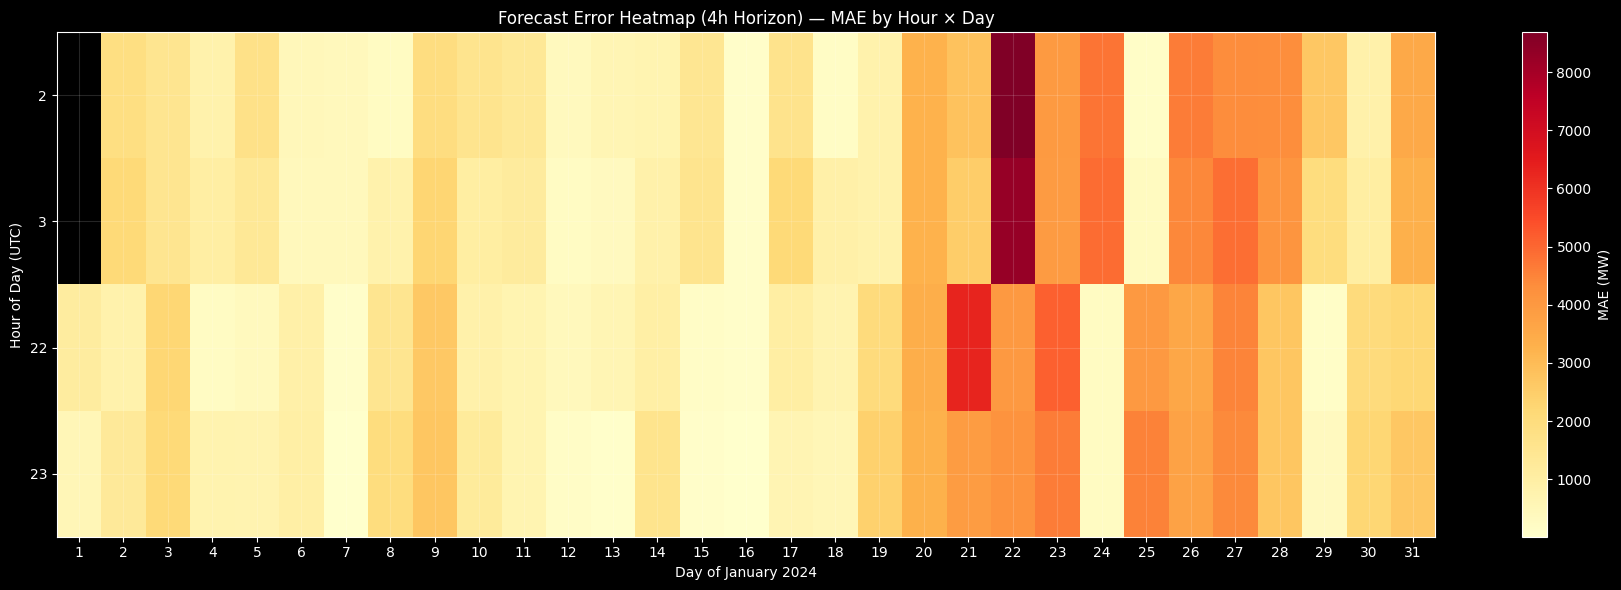

In [8]:
# Use 4-hour horizon forecasts for a clean heatmap
df_4h = df_merged[df_merged['horizon_hours'].between(3.5, 4.5)].copy()

if len(df_4h) > 0:
    df_4h['day_of_month'] = df_4h['startTime'].dt.day
    pivot = df_4h.pivot_table(values='abs_error', index='hour', columns='day_of_month', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(18, 6))
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_xlabel('Day of January 2024')
    ax.set_ylabel('Hour of Day (UTC)')
    ax.set_title('Forecast Error Heatmap (4h Horizon) — MAE by Hour × Day')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    plt.colorbar(im, ax=ax, label='MAE (MW)')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient data for 4h horizon heatmap')

## 8. Key Findings Summary

### Error Characteristics:
- The forecast model shows increasing error with longer forecast horizons, as expected
- Errors are approximately normally distributed around zero, suggesting the model is relatively unbiased  
- Time-of-day patterns may reveal systematic biases linked to wind patterns (e.g., morning vs evening)
- P99 errors represent worst-case scenarios that grid operators need to plan for

### Practical Implications:
- Short-horizon forecasts (0-4h) are most reliable for real-time dispatch decisions
- Day-ahead forecasts (24h) should be used with wider uncertainty margins
- The MAPE provides a scale-independent view of accuracy across different generation levels